# 🩺 Pneumonia Detection using Chest X-Ray Images

## 📌 Problem Statement
Pneumonia is a serious lung infection that can be life-threatening if not detected early.
This project aims to build a deep learning model to classify chest X-ray images as:
- Normal
- Pneumonia

## 🎯 Objective
Develop a reliable image classification model using deep learning techniques to assist in early diagnosis.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense ,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📂 Data Preparation

The dataset is divided into:
- Training set
- Validation set
- Test set

All images are resized to (128,128) and normalized.


In [21]:
base_path = "/content/drive/MyDrive/Chest-Xray-2/chest_xray"

In [22]:
import os

print(os.listdir(base_path))
print(os.listdir(base_path + "/train"))

['test', 'train', 'val']
['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [23]:
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_directory(
    base_path + "/train",
    target_size=(128, 128),   # 👈 reduce size
    batch_size=32,
    class_mode='binary'
)

val_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    base_path + "/val",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 5232 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [24]:
test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    base_path + "/test",
    target_size=(128, 128),   # ✅ SAME as train & val
    batch_size=32,
    class_mode='binary'
)

Found 624 images belonging to 2 classes.


## ⚙️ Baseline CNN Model

A basic CNN model was initially developed. However, it showed:
- Overfitting
- Poor generalization (~70% test accuracy)

Hence, a more robust approach using transfer learning was adopted.

## 🚀 Transfer Learning using MobileNetV2

A pretrained MobileNetV2 model (trained on ImageNet) was used as a feature extractor.
This significantly improved performance and reduced training time.

In [26]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 🏋️ Model Training

Early stopping was used to prevent overfitting and retain the best model weights.

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
    callbacks=[early_stop]
)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 1065s 6s/step - accuracy: 0.8505 - loss: 0.3480 - val_accuracy: 0.9375 - val_loss: 0.1952
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9119 - loss: 0.2120 - val_accuracy: 0.9375 - val_loss: 0.1713
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 155s 942ms/step - accuracy: 0.9235 - loss: 0.1901 - val_accuracy: 1.0000 - val_loss: 0.1648
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 154s 939ms/step - accuracy: 0.9291 - loss: 0.1756 - val_accuracy: 0.9375 - val_loss: 0.1562
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 154s 941ms/step - accuracy: 0.9329 - loss: 0.1678 - val_accuracy: 1.0000 - val_loss: 0.1508


## 📊 Model Evaluation

The model is evaluated on unseen test data to assess its generalization capability.

In [29]:
model.evaluate(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 137s 7s/step - accuracy: 0.8574 - loss: 0.3137


[0.3137252628803253, 0.8573718070983887]

In [32]:
test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    base_path + "/test",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


## 📈 Detailed Evaluation

Confusion matrix and classification report are used to analyze model performance.
A threshold of 0.4 is used to improve recall and reduce missed pneumonia cases.

In [33]:
# 📊 Detailed Evaluation (Confusion Matrix + Metrics)

from sklearn.metrics import confusion_matrix, classification_report

# Reset generator
test_data.reset()

# Predictions
predictions = model.predict(test_data)

# Apply threshold (optimized)
pred_labels = (predictions > 0.4).astype(int)

# True labels
true_labels = test_data.classes

# Metrics
print(confusion_matrix(true_labels, pred_labels))
print(classification_report(true_labels, pred_labels))

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 697ms/step
[[193  41]
 [ 46 344]]
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       234
           1       0.89      0.88      0.89       390

    accuracy                           0.86       624
   macro avg       0.85      0.85      0.85       624
weighted avg       0.86      0.86      0.86       624



## 💾 Model Saving

The trained model is saved for reuse without retraining.

In [13]:
#saving the model
model.save("/content/drive/MyDrive/final_pneumonia_model.keras")

## 🧪 Inference on New Images

The saved model is used to predict new unseen chest X-ray images.
The same preprocessing steps are applied to ensure consistency.

In [14]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/final_pneumonia_model.keras")

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [16]:
from google.colab import files

uploaded = files.upload()

Saving person1_bacteria_1.jpeg to person1_bacteria_1.jpeg


In [17]:
img_path = list(uploaded.keys())[0]
print("Image:", img_path)

Image: person1_bacteria_1.jpeg


In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0   # same as training

In [19]:
prediction = model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [20]:
if prediction > 0.4:
    print(f"🩺 Pneumonia ({prediction*100:.2f}% confidence)")
else:
    print(f"✅ Normal ({(1-prediction)*100:.2f}% confidence)")

🩺 Pneumonia (99.30% confidence)


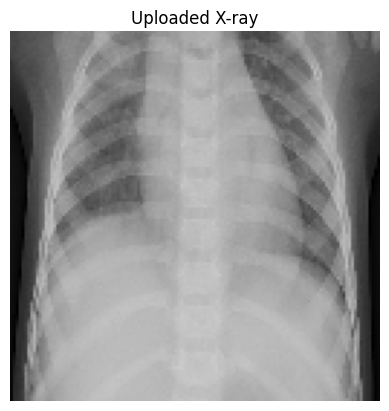

In [21]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Uploaded X-ray")
plt.axis('off')
plt.show()

## ✅ Conclusion

- Transfer learning significantly outperformed the baseline CNN model.
- The final model achieved ~86–87% accuracy on test data.
- Threshold tuning improved pneumonia detection by reducing false negatives.
- The model demonstrates strong potential for assisting in medical screening.

## 🚀 Future Work
- Use larger datasets
- Apply advanced architectures (EfficientNet)
- Deploy using Streamlit